# MITGCM Transect Wind Stress Analysis

**Purpose**: Code for computing the mean fields and spatial gradients along the CalCOFI line 80 transect.  

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import gsw
from geopy.distance import geodesic
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import calendar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from lsf import unweighted_lsf, detrend, compute_amp_phase
import stats
from plotScaleAnalysis import add_freq_marker
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize

Set data analysis parameters

In [3]:
# Set time and space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/regional/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/supplementary_figs/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'
PATH_CCE = ROOT + "AirSeaCoupling"
PATH_calCOFI = ROOT + 'AirSeaCoupling/data/calCOFI/'
PATH_bottom = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'

# Set plotting parameters 
fontsize = 15

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#-------------------------------------------------------#
# MITgcm wind stress Data
#-------------------------------------------------------#
filename_tau = PATH + "mitgcm_intermediate_data_wind_stress_dly_map.nc"
nc_tau = Dataset(filename_tau, 'r')

# Extract data variables
lon = nc_tau.variables['lon_trans'][:]
lat = nc_tau.variables['lat_trans'][:]
dist = nc_tau.variables['dist'][:]
time =  num2date(nc_tau.variables['time'][:], nc_tau.variables['time'].units)

taux_trans = nc_tau.variables['taux_trans'][:]
tauy_trans = nc_tau.variables['tauy_trans'][:]
tau_curl_trans = nc_tau.variables['tau_curl_trans'][:]
tau_div_trans = nc_tau.variables['tau_div_trans'][:]
tau_strain_trans = nc_tau.variables['tau_strain_trans'][:]
tau_mag_trans = nc_tau.variables['tau_mag_trans'][:]
tau_dir_trans = nc_tau.variables['tau_dir_trans'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

#-------------------------------------------------------#
# Ocean Bottom Data
#-------------------------------------------------------#

# Set filename and read in netcdf file
filename = PATH_bottom + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
dist_b = nc.variables['distance'][:]
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Set the locations of each cce mooring

In [5]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53816
lat3 = 34.448512

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Compute probablity density functions

In [48]:
# Set parameters 
ntime, ndist = np.shape(tau_curl_trans)

# Set bin width and edges

#--- Gradients ---#
bin_width = 2*10**(-7)
bin_edges_grad = np.arange(-7.5*10**(-6),7.5*10**(-6)+bin_width,bin_width)
nbins_grad = len(bin_edges_grad) - 1

#--- Magnitude ---#
bin_width_mag = 0.005
bin_edges_mag = np.arange(0,0.5+bin_width_mag,bin_width_mag)
nbins_mag = len(bin_edges_mag) - 1

# Initialize arrays 
pdf_curl = np.full((nbins_grad, ndist), np.nan)
pdf_div = np.full((nbins_grad, ndist), np.nan)
pdf_strain = np.full((nbins_grad, ndist), np.nan)
pdf_mag = np.full((nbins_mag, ndist), np.nan)
tau_curl_median = np.full((ndist, 1), np.nan)
tau_div_median = np.full((ndist, 1), np.nan)
tau_strain_median = np.full((ndist, 1), np.nan)
tau_mag_median = np.full((ndist, 1), np.nan)

# Loop through distance offshore 
for idist in range(0,ndist): 

    # Compute histograms 
    _, tmp_pdf_curl, bin_centers_grad = stats.compute_pdf_1D(tau_curl_trans[:,idist],bin_edges_grad)
    _, tmp_pdf_div, _ = stats.compute_pdf_1D(tau_div_trans[:,idist],bin_edges_grad)
    _, tmp_pdf_strain, _ = stats.compute_pdf_1D(tau_strain_trans[:,idist],bin_edges_grad)
    _, tmp_pdf_mag, bin_centers_mag = stats.compute_pdf_1D(tau_mag_trans[:,idist],bin_edges_mag)

    # Convert to float 
    pdf_curl  = pdf_curl.astype(float)
    pdf_div   = pdf_div.astype(float)
    pdf_strain = pdf_strain.astype(float)
    pdf_mag   = pdf_mag.astype(float)

    # Set Bins with zero counts to NaN
    idx_zeros_pdf_curl = tmp_pdf_curl == 0
    idx_zeros_pdf_div = tmp_pdf_div == 0
    idx_zeros_pdf_strain = tmp_pdf_strain == 0
    idx_zeros_pdf_mag = tmp_pdf_mag == 0

    tmp_pdf_curl[idx_zeros_pdf_curl] = np.nan
    tmp_pdf_div[idx_zeros_pdf_div] = np.nan
    tmp_pdf_strain[idx_zeros_pdf_strain] = np.nan
    tmp_pdf_mag[idx_zeros_pdf_mag] = np.nan

    # Save array in a matrix 
    pdf_curl[:,idist] = tmp_pdf_curl
    pdf_div[:,idist] = tmp_pdf_div
    pdf_strain[:,idist] = tmp_pdf_strain
    pdf_mag[:,idist] = tmp_pdf_mag

    # Compute median 
    tau_curl_median[idist]   = np.median(tau_curl_trans[:,idist])
    tau_div_median[idist]    = np.median(tau_div_trans[:,idist])    
    tau_strain_median[idist] = np.median(tau_strain_trans[:,idist])
    tau_mag_median[idist]    = np.median(tau_mag_trans[:,idist])

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/stats.py:46: RuntimeWarning: invalid value encountered in divide
  pdf = counts / (np.sum(counts) * bin_width)


Compute the seasonal mean, median, and standard deviation for the wind-stress curl

In [22]:
# Set parameters
seasons = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
}

# Define months array for each time step
months = np.array([t.month for t in time.data])

# Removed nearshore points where derivatives are noisy and unreliable
idx_dist = np.where(dist >= 4)[0]
lon_c = lon[idx_dist]
lat_c = lat[idx_dist]
dist_c = dist[idx_dist]

# Set shape of seasonal statistics arrays
ndist = len(dist_c)

# Initialize arrays to hold seasonal statistics
taux_mean_season       = np.full((4, ndist), np.nan)
tauy_mean_season       = np.full((4, ndist), np.nan)
tau_curl_mean_season   = np.full((4, ndist), np.nan)
tau_div_mean_season    = np.full((4, ndist), np.nan)
tau_strain_mean_season = np.full((4, ndist), np.nan)
tau_mag_mean_season    = np.full((4, ndist), np.nan)

tau_curl_median_season   = np.full((4, ndist), np.nan)
tau_div_median_season    = np.full((4, ndist), np.nan)
tau_strain_median_season = np.full((4, ndist), np.nan)
tau_mag_median_season    = np.full((4, ndist), np.nan)

taux_var_season       = np.full((4, ndist), np.nan)
tauy_var_season       = np.full((4, ndist), np.nan)
tau_curl_var_season   = np.full((4, ndist), np.nan)
tau_div_var_season    = np.full((4, ndist), np.nan)
tau_strain_var_season = np.full((4, ndist), np.nan)
tau_mag_var_season    = np.full((4, ndist), np.nan)

taux_stde_season       = np.full((4, ndist), np.nan)
tauy_stde_season       = np.full((4, ndist), np.nan)
tau_curl_stde_season   = np.full((4, ndist), np.nan)
tau_div_stde_season    = np.full((4, ndist), np.nan)
tau_strain_stde_season = np.full((4, ndist), np.nan)
tau_mag_stde_season    = np.full((4, ndist), np.nan)

# Set counter 
cn = 0

# Loop through seasons 
for season_name, season_months in seasons.items():

    # Print season name for debugging
    print(f"Processing season: {season_name}")

    # Define season mask 
    season_mask = np.isin(months, season_months)

    # Obtain seasonal subset of data
    taux_season       =  taux_trans[season_mask, :]
    tauy_season       =  tauy_trans[season_mask, :]
    tau_curl_season   = tau_curl_trans[season_mask, :]
    tau_div_season    = tau_div_trans[season_mask, :]
    tau_strain_season = tau_strain_trans[season_mask, :]
    tau_mag_season    = tau_mag_trans[season_mask, :]

    # Compute seasonal statistics

    #--- Mean ---# 
    taux_mean_season[cn, :]       = np.nanmean(taux_season, axis=0)[idx_dist]
    taux_mean_season[cn, :]       = np.nanmean(taux_season, axis=0)[idx_dist]
    tau_curl_mean_season[cn, :]   = np.nanmean(tau_curl_season, axis=0)[idx_dist]
    tau_div_mean_season[cn, :]    = np.nanmean(tau_div_season, axis=0)[idx_dist]
    tau_strain_mean_season[cn, :] = np.nanmean(tau_strain_season, axis=0)[idx_dist]
    tau_mag_mean_season[cn, :]    = np.nanmean(tau_mag_season, axis=0)[idx_dist]

    #--- Median ---#
    tau_curl_median_season[cn, :]   = np.nanmedian(tau_curl_season, axis=0)[idx_dist]
    tau_div_median_season[cn, :]    = np.nanmedian(tau_div_season, axis=0)[idx_dist]
    tau_strain_median_season[cn, :] = np.nanmedian(tau_strain_season, axis=0)[idx_dist]
    tau_mag_median_season[cn, :]    = np.nanmedian(tau_mag_season, axis=0)[idx_dist]

    #--- Variance ---#
    taux_var_season[cn, :]       = np.nanvar(taux_season, axis=0)[idx_dist]
    tauy_var_season[cn, :]       = np.nanvar(tauy_season, axis=0)[idx_dist]
    tau_curl_var_season[cn, :]   = np.nanvar(tau_curl_season, axis=0)[idx_dist]
    tau_div_var_season[cn, :]    = np.nanvar(tau_div_season, axis=0)[idx_dist]
    tau_strain_var_season[cn, :] = np.nanvar(tau_strain_season, axis=0)[idx_dist]
    tau_mag_var_season[cn, :]    = np.nanvar(tau_mag_season, axis=0)[idx_dist]

    #--- Standard Error ---#
    n_samples_season = np.sum(season_mask)
    taux_stde_season[cn, :]       = np.sqrt(taux_var_season[cn, :] / n_samples_season)
    tauy_stde_season[cn, :]       = np.sqrt(tauy_var_season[cn, :] / n_samples_season)
    tau_curl_stde_season[cn, :]   = np.sqrt(tau_curl_var_season[cn, :] / n_samples_season)
    tau_div_stde_season[cn, :]    = np.sqrt(tau_div_var_season[cn, :] / n_samples_season)
    tau_strain_stde_season[cn, :] = np.sqrt(tau_strain_var_season[cn, :] / n_samples_season)
    tau_mag_stde_season[cn, :]    = np.sqrt(tau_mag_var_season[cn, :] / n_samples_season)

    # Reinitialize counter 
    cn += 1

# Compute standard deviation 
taux_std_season       = np.sqrt(taux_var_season)
tauy_std_season       = np.sqrt(tauy_var_season)
tau_curl_std_season   = np.sqrt(tau_curl_var_season)
tau_div_std_season    = np.sqrt(tau_div_var_season)
tau_strain_std_season = np.sqrt(tau_strain_var_season)
tau_mag_std_season    = np.sqrt(tau_mag_var_season)

# Compute mean, median, variance, and standard error of the mean and variance for the entire time series (all seasons combined)
taux_mean_all      = np.nanmean(taux_trans, axis=0)[idx_dist]
tauy_mean_all      = np.nanmean(tauy_trans, axis=0)[idx_dist]
tau_curl_mean_all  = np.nanmean(tau_curl_trans, axis=0)[idx_dist]
tau_div_mean_all   = np.nanmean(tau_div_trans, axis=0)[idx_dist]
tau_strain_mean_all = np.nanmean(tau_strain_trans, axis=0)[idx_dist]
tau_mag_mean_all    = np.nanmean(tau_mag_trans, axis=0)[idx_dist]

taux_median_all      = np.nanmedian(taux_trans, axis=0)[idx_dist]
tauy_median_all      = np.nanmedian(tauy_trans, axis=0)[idx_dist]
tau_curl_median_all  = np.nanmedian(tau_curl_trans, axis=0)[idx_dist]
tau_div_median_all   = np.nanmedian(tau_div_trans, axis=0)[idx_dist]
tau_strain_median_all = np.nanmedian(tau_strain_trans, axis=0)[idx_dist]
tau_mag_median_all    = np.nanmedian(tau_mag_trans, axis=0)[idx_dist]

taux_var_all       = np.nanvar(taux_trans, axis=0)[idx_dist]
tauy_var_all       = np.nanvar(tauy_trans, axis=0)[idx_dist]  
tau_curl_var_all   = np.nanvar(tau_curl_trans, axis=0)[idx_dist]
tau_div_var_all    = np.nanvar(tau_div_trans, axis=0)[idx_dist]
tau_strain_var_all = np.nanvar(tau_strain_trans, axis=0)[idx_dist]
tau_mag_var_all    = np.nanvar(tau_mag_trans, axis=0)[idx_dist]

# Compute the elapsed time from beginning of time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# Set parameters 
lag = ntime 
estimator = 'biased'
norm = 0
T = time_elapsed[-1] - time_elapsed[0] # Units: seconds

# Initialize array
decor_time = np.full((ndist), np.nan)

# Loop through distance offshore
for idist in range(0,ndist):

    # Extract time series at the ith distance offshore
    tmp = tau_curl_trans[:, idist]
    
    # Detrend data record 
    tmp_dt = detrend(tmp, time_elapsed, mean = 0)

    # Compute autocorrelation and decorrelation scale 
    autocorr, _, _, _, time_lag, _ = compute_autocorr_optimize(tmp_dt, time_elapsed, lag, estimator, norm)

    # Compute the decorrelation scale
    decor_time[idist] = compute_decor_scale_optimize(autocorr,time_lag,T,'unbiased',0) # Units: seconds

# Compute the number of degrees of freedom at each site
decor_time_days = decor_time / 86400  # Convert decorrelation time from seconds to days
T_days = T / 86400  # Convert total time span from seconds to days
N_eff = np.minimum(T_days / decor_time_days, ntime)

# Compute standard error of the mean and variance for the entire time series (all seasons combined)
taux_stdm_all       = np.sqrt(taux_var_all / ntime)
tauy_stdm_all       = np.sqrt(tauy_var_all / ntime)
tau_curl_stdm_all   = np.sqrt(tau_curl_var_all / N_eff)
tau_div_stdm_all    = np.sqrt(tau_div_var_all / ntime)
tau_strain_stdm_all = np.sqrt(tau_strain_var_all / ntime)
tau_mag_stdm_all    = np.sqrt(tau_mag_var_all / ntime)

taux_stdv_all      = taux_var_all * np.sqrt(2/(ntime-1))
tauy_stdv_all      = tauy_var_all * np.sqrt(2/(ntime-1))
tau_curl_stdv_all  = tau_curl_var_all * np.sqrt(2/(N_eff-1))
tau_div_stdv_all   = tau_div_var_all * np.sqrt(2/(ntime-1))
tau_strain_stdv_all = tau_strain_var_all * np.sqrt(2/(ntime-1))
tau_mag_stdv_all    = tau_mag_var_all * np.sqrt(2/(ntime-1))

Processing season: DJF
Processing season: MAM
Processing season: JJA
Processing season: SON


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_11156/3515030401.py:80: RuntimeWarning: All-NaN slice encountered
  tau_div_median_season[cn, :]    = np.nanmedian(tau_div_season, axis=0)[idx_dist]
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_11156/3515030401.py:81: RuntimeWarning: All-NaN slice encountered
  tau_strain_median_season[cn, :] = np.nanmedian(tau_strain_season, axis=0)[idx_dist]
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Plot the seasonal statistics for wind-stress curl  

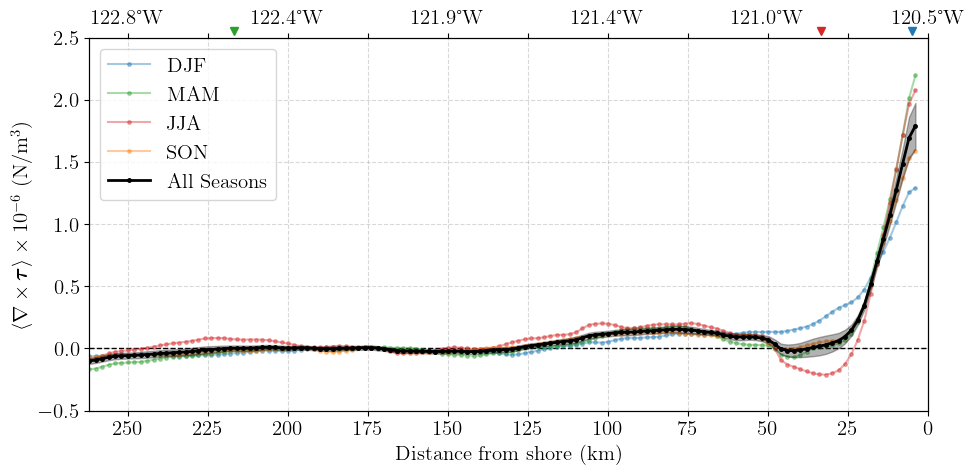

In [8]:
# Set plotting parameters
season_colors = {
    'DJF': 'tab:blue',
    'MAM': 'tab:green',
    'JJA': 'tab:red',
    'SON': 'tab:orange',
}

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the zero line 
ax.axhline(0, color='k', linestyle='--', linewidth=1)

# Plot the mean wind stress curl for each season
ax.plot(dist_c, tau_curl_mean_season[0,:]*10**6, '.-', color='tab:blue', linewidth=1.5, label='DJF', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_mean_season[1,:]*10**6, '.-', color='tab:green', linewidth=1.5, label='MAM', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_mean_season[2,:]*10**6, '.-', color='tab:red', linewidth=1.5, label='JJA', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_mean_season[3,:]*10**6, '.-', color='tab:orange', linewidth=1.5, label='SON', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_mean_all*10**6, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the mean as shaded area around the mean
ax.fill_between(dist_c, tau_curl_mean_all*10**6 - tau_curl_stdm_all*10**6, tau_curl_mean_all*10**6 + tau_curl_stdm_all*10**6, color='k', alpha=0.3, zorder=3)

# Axis formatting
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$\langle \nabla \times \boldsymbol{\tau} \rangle \times 10^{-6}$ (N/m$^3$)')
ax.set_xticks(np.arange(0, 250 + 25, 25))
ax.set_xlim(0, dist_c[-1])
ax.set_ylim(-0.5, 2.5)
ax.invert_xaxis()
ax.grid(linestyle='--', alpha=0.3, color='grey')
ax.legend(loc='upper left')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

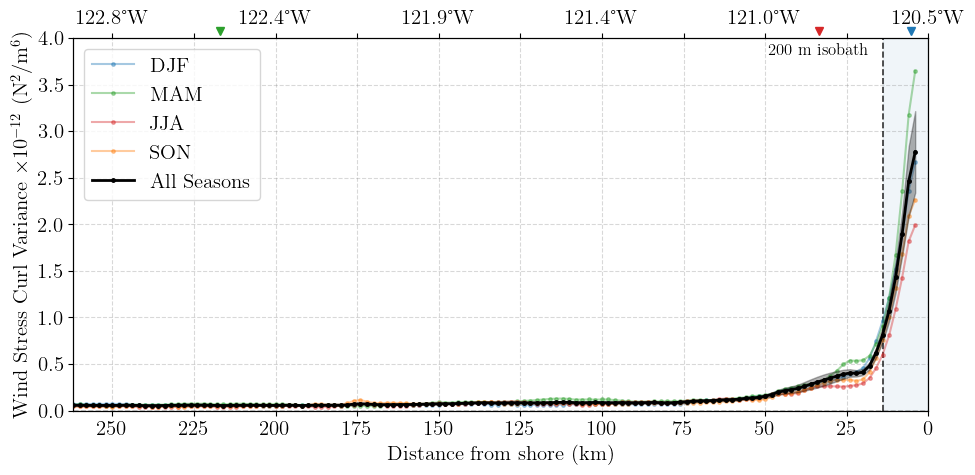

In [65]:
# Set plotting parameters
season_colors = {
    'DJF': 'tab:blue',
    'MAM': 'tab:green',
    'JJA': 'tab:red',
    'SON': 'tab:orange',
}

# Set the index of the coastline (where bottom depth is closest to 200 m)
idx_coast = np.argmin(np.abs(np.abs(bottom_depth) - 200))

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Shade the coastal ocean (coastline to 200m isobath)
ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Add label for 200 m isobath
ax.text(dist_b[idx_coast] + 35, 0.985, '200 m isobath', 
        transform=ax.get_xaxis_transform(),
        ha='left', va='top', fontsize=12, color='k', rotation=0)

# Plot the zero line 
ax.axhline(0, color='k', linestyle='--', linewidth=1)

# Plot the mean wind stress curl for each season
ax.plot(dist_c, tau_curl_var_season[0,:]*10**12, '.-', color='tab:blue', linewidth=1.5, label='DJF', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_var_season[1,:]*10**12, '.-', color='tab:green', linewidth=1.5, label='MAM', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_var_season[2,:]*10**12, '.-', color='tab:red', linewidth=1.5, label='JJA', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_var_season[3,:]*10**12, '.-', color='tab:orange', linewidth=1.5, label='SON', alpha=0.4, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_var_all*10**12, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the variance as shaded area around the mean
ax.fill_between(dist_c, tau_curl_var_all*10**12 - tau_curl_stdv_all*10**12, tau_curl_var_all*10**12 + tau_curl_stdv_all*10**12, color='k', alpha=0.3, zorder=3)

# Axis formatting
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'Wind Stress Curl Variance $\times 10^{-12}$ (N$^2$/m$^6$)')
ax.set_xticks(np.arange(0, 250 + 25, 25))
ax.set_xlim(0, dist_c[-1])
ax.set_ylim(0, 4)
ax.invert_xaxis()
ax.grid(linestyle='--', alpha=0.3, color='grey')
ax.legend(loc='upper left')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

Plot box and wisket plots along the transect for each wind stress variable

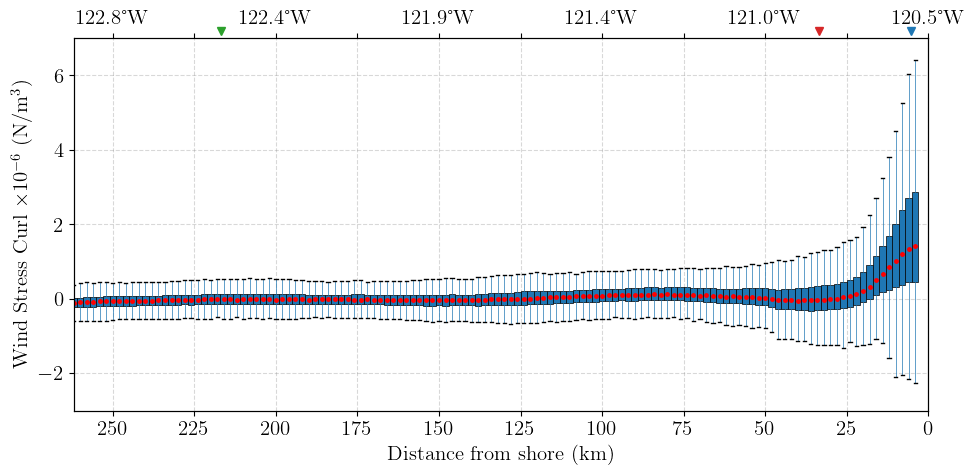

In [41]:
# Set plotting parameters
tau_curl_list = [tau_curl_trans[:,i]*10**6 for i in range(tau_curl_trans.shape[1]) if dist[i] >= 4]

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot box plot 
ax.boxplot(tau_curl_list, positions=dist_c, vert=True, patch_artist=True, widths=2, showfliers=False, manage_ticks=False,  
            medianprops=dict(linestyle='none'), 
            boxprops=dict(color='k',          
                          linewidth=0.5,          
                          linestyle='--'), 
            whiskerprops=dict(linewidth=0.5, 
                              color='#1f77b4', 
                              linestyle='-'))

# Plot median wind-stress curl 
ax.plot(dist_c,tau_curl_median_all*10**6,'.', color='red', markerfacecolor='red', markersize=5, label='Median')

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'Wind Stress Curl $\times 10^{-6}$ (N/m$^3$)')
ax.set_xticks(np.arange(0,250+25,25))
ax.set_xlim(0,dist_c[-1])
ax.set_ylim(-3, 7)
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_11156/4157619611.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


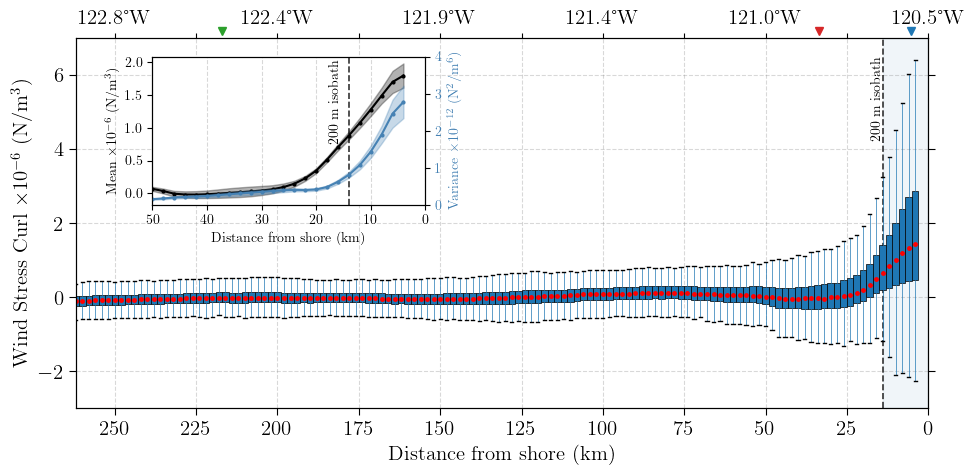

In [11]:
# Set plotting parameters
tau_curl_list = [tau_curl_trans[:,i]*10**6 for i in range(tau_curl_trans.shape[1]) if dist[i] >= 4]
fontsize = 10

# Set the index of the coastline (where bottom depth is closest to 200 m)
idx_coast = np.argmin(np.abs(np.abs(bottom_depth) - 200))

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Main Axis ---# 

# Shade the coastal ocean (coastline to 200m isobath)
ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Plot box plot 
ax.boxplot(tau_curl_list, positions=dist_c, vert=True, patch_artist=True, widths=2, showfliers=False, manage_ticks=False,  
            medianprops=dict(linestyle='none'), 
            boxprops=dict(color='k',          
                          linewidth=0.5,          
                          linestyle='--'), 
            whiskerprops=dict(linewidth=0.5, 
                              color='#1f77b4', 
                              linestyle='-'))

# Plot median wind-stress curl 
ax.plot(dist_c, tau_curl_median_all*10**6, '.', color='red', markerfacecolor='red', markersize=5, label='Median')


# Add label for 200 m isobath
ax.text(dist_b[idx_coast] + 3.5, 0.95, '200 m isobath', 
        transform=ax.get_xaxis_transform(),
        ha='left', va='top', fontsize=fontsize, color='k', rotation=90)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'Wind Stress Curl $\times 10^{-6}$ (N/m$^3$)')
ax.set_xticks(np.arange(0, 250+25, 25))
ax.set_xlim(0, dist_c[-1])
ax.set_ylim(-3, 7)
ax.invert_xaxis()
ax.grid(linestyle='--', alpha=0.3, color='grey')
ax.tick_params(which='both', direction='out', top=True, right=True, left=True, bottom=True, length=5)

# --- Inset axis (zoomed, 0–50 km, mean and variance) --- #

# Set position and size of inset 
ax_inset = ax.inset_axes([0.09, 0.55, 0.32, 0.40])  # adjust as needed

# Mask to nearshore points only
nearshore_mask = dist_c <= 50

# Twin the inset for variance (different y-scale)
ax_inset2 = ax_inset.twinx()

# Plot wind stress curl variance 
ax_inset2.plot(dist_c[nearshore_mask], tau_curl_var_all[nearshore_mask]*10**12,
               '.-', color='steelblue', linewidth=1.5, markersize=4, label='Variance')

# Plot wind stress curl variance standard error 
ax_inset2.fill_between(dist_c[nearshore_mask], tau_curl_var_all[nearshore_mask]*10**12 - tau_curl_stdv_all[nearshore_mask]*10**12, tau_curl_var_all[nearshore_mask]*10**12 + tau_curl_stdv_all[nearshore_mask]*10**12, color='steelblue', alpha=0.3, zorder=3)

# Set inset axis attributes
ax_inset2.set_ylabel(r'Variance $\times 10^{-12}$ (N$^2$/m$^6$)', fontsize=fontsize, color='steelblue')
ax_inset2.tick_params(axis='y', labelcolor='steelblue', labelsize=fontsize)
ax_inset2.set_ylim(0, 4)

# Plot mean wind stress curl
ax_inset.plot(dist_c[nearshore_mask], tau_curl_mean_all[nearshore_mask]*10**6,
              '.-', color='k', linewidth=1.5, markersize=4, label='Mean')

# Plot wind stress curl standard error
ax_inset.fill_between(dist_c[nearshore_mask], tau_curl_mean_all[nearshore_mask]*10**6 - tau_curl_stdm_all[nearshore_mask]*10**6, tau_curl_mean_all[nearshore_mask]*10**6 + tau_curl_stdm_all[nearshore_mask]*10**6, color='k', alpha=0.3, zorder=3)

# Denote the coastal ocean (coastline to 200m isobath)
ax_inset.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Add label for 200 m isobath
ax_inset.text(dist_b[idx_coast] + 3.5, 0.98, '200 m isobath', 
        transform=ax_inset.get_xaxis_transform(),
        ha='left', va='top', fontsize=fontsize, color='k', rotation=90)

# Set inset axis attributes
ax_inset.set_ylabel(r'Mean $\times 10^{-6}$ (N/m$^3$)', fontsize=fontsize)
ax_inset.set_xlabel('Distance from shore (km)', fontsize=fontsize)
ax_inset.tick_params(labelsize=fontsize)
ax_inset.invert_xaxis()
ax_inset.grid(axis='x', linestyle='--', alpha=0.3, color='grey')
ax_inset.set_xlim(50, 0)

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

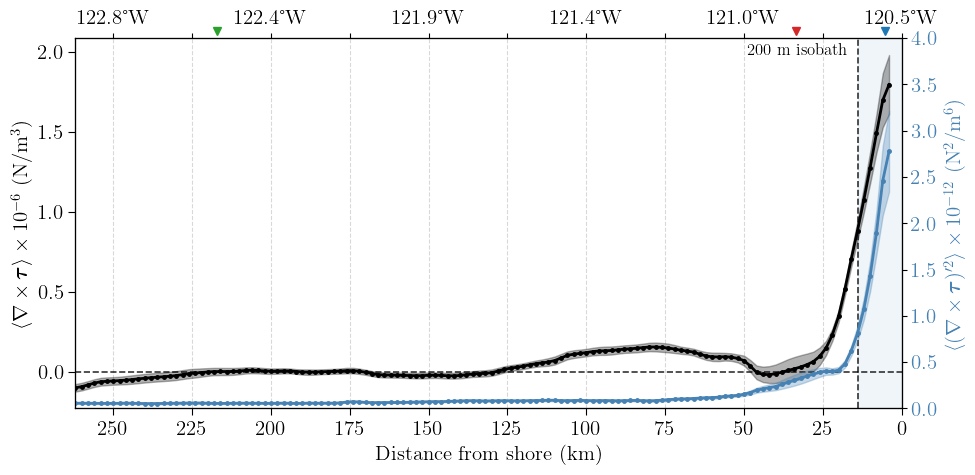

In [19]:
# Set the index of the coastline (where bottom depth is closest to 200 m)
idx_coast = np.argmin(np.abs(np.abs(bottom_depth) - 200))
fontsize = 15

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

# Twin the axis for variance 
ax_twin = ax.twinx()

#--- Mean wind stress curl ---# 

# Shade the coastal ocean (coastline to 200m isobath)
ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Plot horizontal line for zero crossing
ax.axhline(0, color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Add label for 200 m isobath
ax.text(dist_b[idx_coast] + 35, 0.985, '200 m isobath', 
        transform=ax.get_xaxis_transform(),
        ha='left', va='top', fontsize=12, color='k', rotation=0)

# Plot the mean wind stress curl for each season
ax.plot(dist_c, tau_curl_mean_all*10**6, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the mean as shaded area around the mean
ax.fill_between(dist_c, tau_curl_mean_all*10**6 - tau_curl_stdm_all*10**6, tau_curl_mean_all*10**6 + tau_curl_stdm_all*10**6, color='k', alpha=0.3, zorder=3)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$\langle \nabla \times \boldsymbol{\tau} \rangle \times 10^{-6}$ (N/m$^3$)')
ax.set_xticks(np.arange(0, 250+25, 25))
ax.set_xlim(0, dist_c[-1])
ax.invert_xaxis()
ax.grid(axis= 'x', linestyle='--', alpha=0.3, color='grey')
ax.tick_params(which='both', direction='out', top=True, right=False, left=True, bottom=True, length=5)

#--- Variance wind stress curl ---# 

# Plot the mean wind stress curl for each season
ax_twin.plot(dist_c, tau_curl_var_all*10**12, '.-', color='steelblue', linewidth=2, label='All Seasons', markersize=5)

# Plot the standard error of the variance as shaded area around the mean
ax_twin.fill_between(dist_c, tau_curl_var_all*10**12 - tau_curl_stdv_all*10**12, tau_curl_var_all*10**12 + tau_curl_stdv_all*10**12, color='steelblue', alpha=0.3, zorder=3)

# Set axis attributes
ax_twin.set_ylabel(r"$\langle (\nabla \times \boldsymbol{\tau})'^2 \rangle \times 10^{-12}$ (N$^2$/m$^6$)", color='steelblue')
ax_twin.tick_params(axis='y', labelcolor='steelblue', labelsize=fontsize)
ax_twin.set_ylim(0, 4)

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

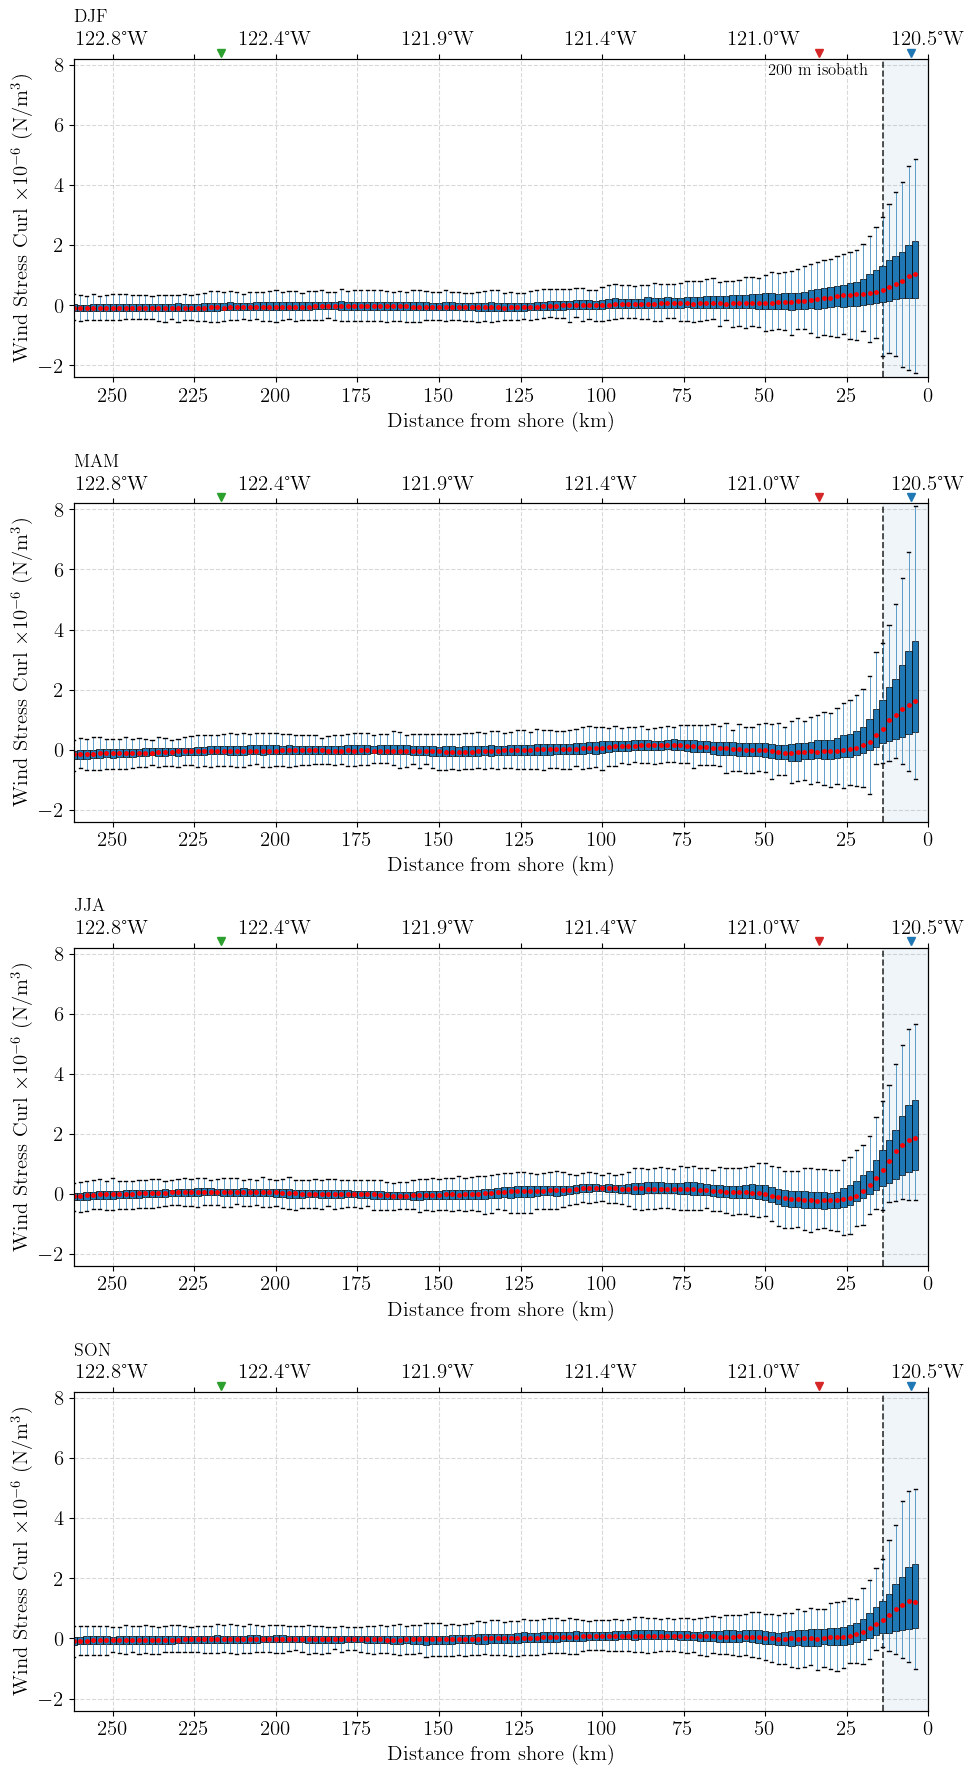

In [64]:
# --- Season definitions ---
seasons = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
}
months = np.array([t.month for t in time.data])

# --- Create figure: 4 rows, 1 column ---
fig, axes = plt.subplots(4, 1, figsize=(10, 18), sharex=False)
fig.subplots_adjust(hspace=0.45)

# Precompute shared lon info (used by all subplots)
lon_180 = ((lon + 180) % 360) - 180
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

for ax, (season_name, season_months) in zip(axes, seasons.items()):

    # --- Subset tau_curl_trans by season ---
    season_mask = np.isin(months, season_months)
    tau_curl_season = tau_curl_trans[season_mask, :]  # shape: (n_season_times, n_dist)

    # --- Compute seasonal median ---
    tau_curl_median_iseason = np.nanmedian(tau_curl_season, axis=0)

    # --- Filter by distance >= 4 km ---
    idx_dist = np.where(dist >= 4)[0]
    tau_curl_list = [tau_curl_season[:, i]*10**6 for i in idx_dist]
    dist_c = dist[idx_dist]
    tau_curl_median_c_iseason = tau_curl_median_iseason[idx_dist]*10**6

    # Shade the coastal ocean (coastline to 200m isobath)
    ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
    ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

    if season_name == 'DJF': 
        
        # Add label for 200 m isobath
        ax.text(dist_b[idx_coast] + 35, 0.985, '200 m isobath', 
                transform=ax.get_xaxis_transform(),
                ha='left', va='top', fontsize=12, color='k', rotation=0)

    # --- Box plot ---
    ax.boxplot(
        tau_curl_list,
        positions=dist_c,
        vert=True,
        patch_artist=True,
        widths=2,
        showfliers=False,
        manage_ticks=False,
        medianprops=dict(linestyle='none'),
        boxprops=dict(color='k', linewidth=0.5, linestyle='--'),
        whiskerprops=dict(linewidth=0.5, color='#1f77b4', linestyle='-'),
    )

    # --- Median line ---
    ax.plot(dist_c, tau_curl_median_c_iseason, '.', color='red',
            markerfacecolor='red', markersize=5, label='Median')

    # --- Axis formatting ---
    ax.set_title(season_name, fontsize=13, fontweight='bold', loc='left')
    ax.set_xlabel('Distance from shore (km)')
    ax.set_ylabel(r'Wind Stress Curl $\times 10^{-6}$ (N/m$^3$)')
    ax.set_xticks(np.arange(0, 250 + 25, 25))
    ax.set_xlim(0, dist_c[-1])
    ax.set_ylim(-2.4, 8.2)
    ax.invert_xaxis()
    ax.grid(linestyle='--', alpha=0.3, color='grey')

    # --- Set top longitude axis --- # 
    ax_top = ax.twiny()

    # Set  limits of top axis and reverse order 
    ax_top.set_xlim(0, dist_c[-1])
    ax_top.invert_xaxis()

    # Obtain distance ticks from bottom axis
    dist_ticks = ax.get_xticks()

    # Interpolate longitude ticks at the position of the bottom axis tick positions
    lon_180 = ((lon + 180) % 360) - 180
    lon_ticks = np.interp(dist_ticks, dist, lon_180)

    # Set the ticklabels on the longitude ticks for the top axis
    labels = [
        f"{abs(x):.1f}°W" if i % 2 == 0 else ""
        for i, x in enumerate(lon_ticks)
    ]

    # Set the ticks location and tick labels for the top axis
    ax_top.set_xticks(dist_ticks)
    ax_top.set_xticklabels(labels)

    # Sort lon so it is monotonically increasing for interpolation 
    sort_idx = np.argsort(lon_180)
    lon_sorted = lon_180[sort_idx]
    dist_sorted = dist[sort_idx]

    # Interpolate the position of each mooring onto distance from shore
    dist1 = np.interp(lon1, lon_sorted, dist_sorted)
    dist2 = np.interp(lon2, lon_sorted, dist_sorted)
    dist3 = np.interp(lon3, lon_sorted, dist_sorted)

    add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                    markerfacecolor='tab:green', markeredgecolor='tab:green')
    add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                    markerfacecolor='tab:red', markeredgecolor='tab:red')
    add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                    markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

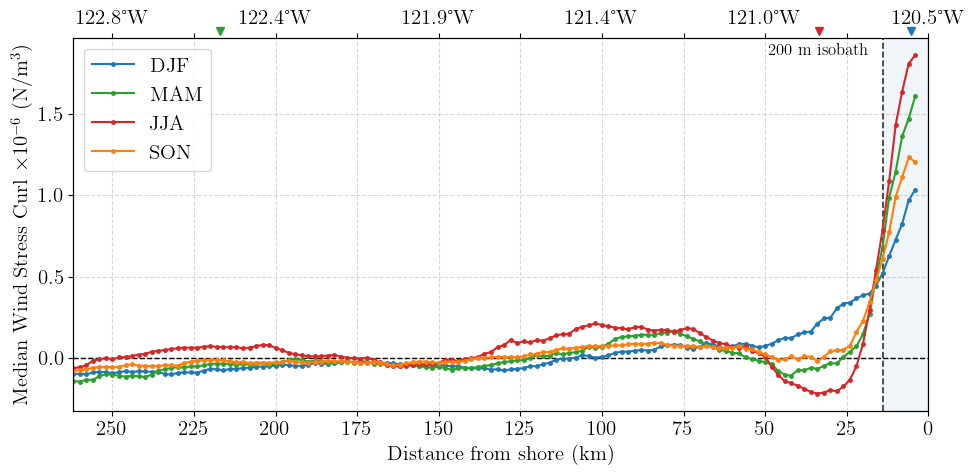

In [62]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Shade the coastal ocean (coastline to 200m isobath)
ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Add label for 200 m isobath
ax.text(dist_b[idx_coast] + 35, 0.985, '200 m isobath', 
        transform=ax.get_xaxis_transform(),
        ha='left', va='top', fontsize=12, color='k', rotation=0)

# Plot the zero line 
ax.axhline(0, color='k', linestyle='--', linewidth=1)

# Plot median wind stress curl
ax.plot(dist_c, tau_curl_median_season[0,:]*10**6, '.-', color='tab:blue', linewidth=1.5, label='DJF', alpha=1, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_median_season[1,:]*10**6, '.-', color='tab:green', linewidth=1.5, label='MAM', alpha=1, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_median_season[2,:]*10**6, '.-', color='tab:red', linewidth=1.5, label='JJA', alpha=1, zorder=2, markersize=5)
ax.plot(dist_c, tau_curl_median_season[3,:]*10**6, '.-', color='tab:orange', linewidth=1.5, label='SON', alpha=1, zorder=2, markersize=5)

# Axis formatting
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'Median Wind Stress Curl $\times 10^{-6}$ (N/m$^3$)')
ax.set_xticks(np.arange(0, 250 + 25, 25))
ax.set_xlim(0, dist_c[-1])
#ax.set_ylim(-0.005, 0.025)
ax.invert_xaxis()
ax.grid(linestyle='--', alpha=0.3, color='grey')
ax.legend(loc='upper left')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()

Plot the PDF as a function of distance from shore for wind-stress curl

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_11156/1603955387.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(dist_c,tau_curl_median_all*10**6,'.-', color='red',linestyle='-',linewidth=1)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_11156/1603955387.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


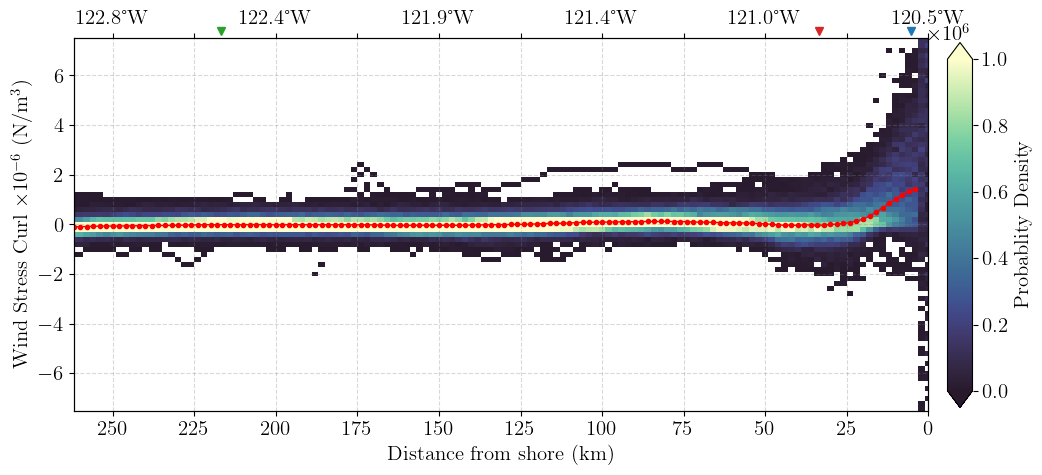

In [55]:
# Set plotting parameter
cmap = cmo.deep_r

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
pc = ax.pcolormesh(dist,bin_centers_grad*10**6,pdf_curl, vmin=0, vmax=1000000, cmap=cmap)

# Plot the median value 
ax.plot(dist_c,tau_curl_median_all*10**6,'.-', color='red',linestyle='-',linewidth=1)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'Wind Stress Curl $\times 10^{-6}$ (N/m$^3$)')
ax.set_xlim(0,dist_c[-1])
#ax.set_ylim(-0.075,0.075)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both')
cbar.set_label('Probablity Density')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()


/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_11156/421246165.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(dist,tau_mag_median,'.-', color='red',linestyle='-',linewidth=1)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_11156/421246165.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


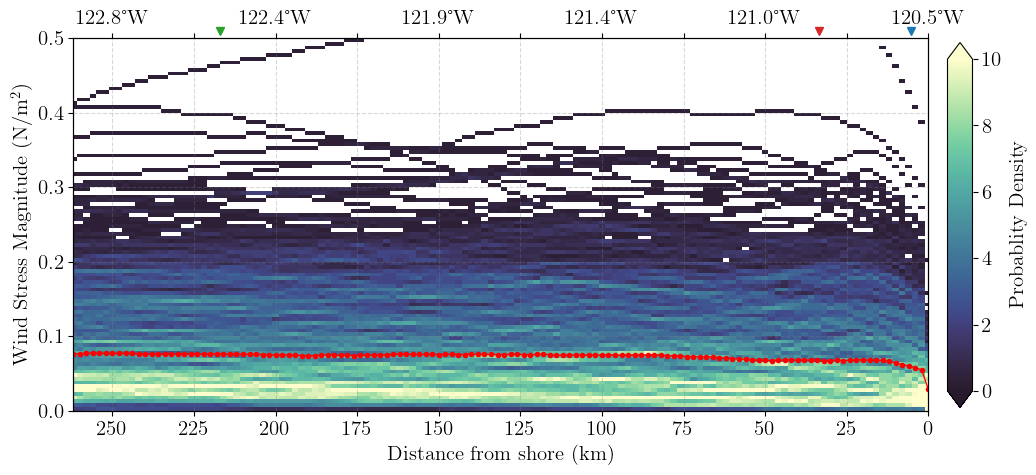

In [34]:
# Set plotting parameter
cmap = cmo.deep_r

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
pc = ax.pcolormesh(dist,bin_centers_mag,pdf_mag, vmin=0, vmax=10, cmap=cmap)

# Plot the median value 
ax.plot(dist,tau_mag_median,'.-', color='red',linestyle='-',linewidth=1)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'Wind Stress Magnitude (N/m$^2$)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,0.5)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both')
cbar.set_label('Probablity Density')
#cbar.set_ticks(np.arange(15,40+5,5))

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, dist_c[-1])
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.02, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Show figure
plt.tight_layout()
plt.show()


Save intermediate data 

In [59]:
#--- Wind Stress statistics ---# 

# Check if file exists, then delete it
file_path = PATH + "/mitgcm_transect_wind_stress_stats_CalCOFI_line80.npz"
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal statistic of Wind Stress from the MITgcm model out of along CalCOFI line 80.',
    'source': 'MITgcm model data from SWOT_MARA_RUN4_LY',
    'coordinates units': 'km'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
            tau_curl_trans       = tau_curl_trans, 
            tau_curl_median_all  = tau_curl_median_all,
            tau_curl_mean_all    = tau_curl_mean_all,  
            tau_curl_stdm_all    = tau_curl_stdm_all, 
            tau_curl_var_all     = tau_curl_var_all,  
            tau_curl_stdv_all    = tau_curl_stdv_all,     
            dist_c               = dist_c,
            lon                  = lon_c,
            lat                  = lat_c, 
            time                 = time, 
            metadata             = metadata
            )

In [58]:
np.shape(dist)

(132,)

### Developmental Code

In [ ]:
# Draw a box on the main axis indicating the inset region
#ax.indicate_inset_zoom(ax_inset, edgecolor='k', alpha=0.3)

# Add combined legend for inset
# lines1, labels1 = ax_inset.get_legend_handles_labels()
# lines2, labels2 = ax_inset2.get_legend_handles_labels()
# ax_inset.legend(lines1 + lines2, labels1 + labels2, fontsize=fontsize, loc='upper left')

# Add a bracket-style annotation along the top of the shaded region
# ax.annotate('', 
#             xy=(0, 0.10), xycoords=('data', 'axes fraction'),
#             xytext=(dist_b[idx_coast], 0.10), textcoords=('data', 'axes fraction'),
#             arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.2))

# ax.text(dist_b[idx_coast] / 2, 0.97, 'Coastal Ocean\n(< 200 m isobath)', 
#         transform=ax.get_xaxis_transform(),
#         ha='center', va='bottom', fontsize=8, color='brown')